**Asignatura:** Inteligencia en Negocios Globales — Universidad EAN  
**Proyecto final — Grupo 6**  
**Producto:** Curuba (*Passiflora mollissima*), NANDINA 0810.90.10.40. En Trade Map solo existe **HS 081090**, que agrupa curuba con maracuyá, pitahaya y otros; el equipo usa un factor de imputación del 3,8 % para aislarla.  
**Ficha técnica de referencia:** *Equipo 6 — Ficha técnica del estudio: metodología y plan de minería de datos* y su paquete `Anexo_Datos_Curuba_Equipo6`. Como el paquete separa **datos reales de Trade Map** de **estimaciones del equipo**, este cuaderno marca en cada sección cuál de las dos capas usa. La vista por destino de HS 081090 y los datos del Banco Mundial, pendientes en el plan del equipo, se tomaron de la carpeta del grupo 1 y de `data/` del curso.

***

## La pregunta del equipo

> ¿Cómo puede una empresa exportadora colombiana de curuba fresca diseñar una estrategia de entrada que concentre su oferta en uno o dos mercados prioritarios, apoyada en un manejo poscosecha que garantice la calidad durante el trayecto logístico?

## Lo que calcula este cuaderno

Cada sección corresponde a un análisis que el equipo propuso en su ficha técnica. El cuaderno **calcula y grafica; no interpreta**. La interpretación es el trabajo del equipo.

| Métrica o análisis | Pregunta que responde |
|---|---|
| **Oferta mundial de HS 081090** | ¿Quién exporta, cuánto crece cada uno y dónde están Colombia, Ecuador y Perú? |
| **HHI de la oferta mundial** | ¿El mercado mundial se concentra o se fragmenta? |
| **IBCR, IAC y CE** | ¿Qué economías son mercados de consumo y cuáles hubs de reexportación? |
| **HHI, Theil y Grubel-Lloyd de Colombia** | ¿Qué tan dispersos están los destinos colombianos y qué tipo de comercio es? |
| **Balassa, RSCA y Lafay** | ¿Colombia, Ecuador y Perú tienen ventaja revelada en esta subpartida? |
| **Matriz multicriterio** | ¿Qué mercado prioriza la estrategia de entrada y qué tan sensible es a los pesos? |
| **Sensibilidad al factor de imputación** | ¿Cuánto cambian las cifras de curuba si el 3,8 % fuera 12,5 %? |

## Cómo usar este cuaderno

1. Ejecuta las celdas **en orden**, de arriba hacia abajo (`Entorno de ejecución → Ejecutar todas`). Viene en modo `"github"`: descarga sus propios datos del repositorio del curso, no tienes que subir nada.  
2. Después de cada gráfica hay una celda que dice **Análisis del equipo**. Haz doble clic sobre ella y escribe la interpretación. Puedes agregar más celdas de texto donde quieras.  
3. Las celdas marcadas **editable** contienen pesos o puntajes que el equipo debe ajustar con su propio criterio. Cámbialos y vuelve a ejecutar.  
4. Al terminar: `Archivo → Descargar → Descargar .ipynb` y sube el archivo al aula virtual.

Todas las tablas y figuras se guardan además en la carpeta `salidas/` (panel izquierdo de Colab) para que las uses en el informe.

***
# 0. Preparación del entorno

In [1]:
import os
import io
import csv
import glob
import time
import shutil
import zipfile
import urllib.request
import urllib.error
import urllib.parse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 170)

# Paleta de colores del curso (validada para lectura accesible en pantalla e impresion)
AZUL      = "#2a78d6"    # serie principal / pais del caso
ROJO      = "#e34948"    # valores negativos (par divergente con el azul)
NARANJA   = "#eb6834"    # elemento destacado
VERDE     = "#3f8f6b"    # segunda serie categorica
GRIS_MID  = "#c3c2b7"    # resto / punto neutro
TINTA     = "#0b0b0b"
GRIS_TEXT = "#52514e"
GRIS_EJE  = "#898781"
REJILLA   = "#e1e0d9"

# Orden fijo de colores para series categoricas: nunca se reciclan, lo que sobra va a "Otros" en gris
CATEGORIAS = [AZUL, NARANJA, VERDE, ROJO]

CARPETA_SALIDA = "salidas"
os.makedirs(CARPETA_SALIDA, exist_ok=True)


def estilo(ax, titulo, subtitulo="", fuente="", eje_y="", eje_x="", rejilla="y"):
    """Aplica el estilo de graficas del curso: titulo a la izquierda, sin marco, rejilla suave, fuente al pie."""
    ax.set_title(titulo + ("\n" + subtitulo if subtitulo else ""),
                 fontsize=13, color=TINTA, loc="left", pad=14)
    ax.set_ylabel(eje_y, fontsize=10, color=GRIS_TEXT)
    ax.set_xlabel(eje_x, fontsize=10, color=GRIS_TEXT)
    if rejilla == "y":
        ax.yaxis.grid(True, color=REJILLA, linewidth=0.8)
    elif rejilla == "x":
        ax.xaxis.grid(True, color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(GRIS_EJE)
    ax.tick_params(colors=GRIS_EJE, labelsize=9)
    if fuente:
        ax.figure.text(0.01, -0.03, "Fuente: " + fuente, fontsize=8, color=GRIS_EJE, ha="left")


def guardar(fig, nombre):
    """Muestra la figura y la guarda como PNG en la carpeta de salidas."""
    ruta = os.path.join(CARPETA_SALIDA, nombre + ".png")
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada en", ruta)


def exportar(tabla, nombre):
    """Guarda una tabla como CSV en la carpeta de salidas y la devuelve para mostrarla."""
    tabla.to_csv(os.path.join(CARPETA_SALIDA, nombre + ".csv"), index=False, encoding="utf-8-sig")
    return tabla


def fmt_miles(x, _=None):
    """Formato de eje para valores en miles de USD: 1200 -> 1.2 mn ; 850 -> 850 k."""
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.1f} mil mn"
    if abs(x) >= 1_000:
        return f"{x / 1_000:.1f} mn"
    return f"{x:.0f} k"


def fmt_unidades(x, _=None):
    """Formato de eje para valores en unidades: 1.5e9 -> 1.5 mil mn ; 2.4e6 -> 2.4 mn ; 850000 -> 850 k."""
    if abs(x) >= 1e9:
        return f"{x / 1e9:.1f} mil mn"
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f} mn"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.0f} k"
    return f"{x:.0f}"


def leyenda_fuera(ax):
    """Leyenda a la derecha del grafico, para que no tape barras ni la nota de fuente."""
    ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))


print("pandas:", pd.__version__, "| numpy:", np.__version__)

pandas: 2.2.3 | numpy: 2.1.3


In [2]:
# ============================================================
#  CONFIGURACION: cambia solo esta celda si lo necesitas
# ============================================================

MODO = "github"         # opciones: "github" | "subir" | "local"

REPO_CURSO = "YourFavouriteDataSuperstar/Inteligencia-de-negocios-globales"
RAMA = "main"

# Archivos que necesita este cuaderno, con su ruta dentro del repositorio del curso.
# Los del grupo estan en "Proyectos finales/Grupo 6/datos/"; los demas son datos del curso en "data/".
ARCHIVOS_REPO = {
    "t2_largo": "Proyectos finales/Grupo 6/datos/Anexo_Datos_Curuba_Equipo6/03_datos_limpios/t2_exportadores_081090_largo.csv",
    "t3_mundo": "Proyectos finales/Grupo 6/datos/Anexo_Datos_Curuba_Equipo6/03_datos_limpios/t3_mundo_081090.csv",
    "c1_produccion": "Proyectos finales/Grupo 6/datos/Anexo_Datos_Curuba_Equipo6/03_datos_limpios/c1_produccion_curuba.csv",
    "c2_derivados": "Proyectos finales/Grupo 6/datos/Anexo_Datos_Curuba_Equipo6/03_datos_limpios/c2_produccion_derivados.csv",
    "d1_flujos": "Proyectos finales/Grupo 6/datos/Anexo_Datos_Curuba_Equipo6/03_datos_limpios/d1_flujos_pais_081090.csv",
    "i4_matriz": "Proyectos finales/Grupo 6/datos/Anexo_Datos_Curuba_Equipo6/05_indicadores_equipo/i4_matriz_multicriterio.csv",
    "r6_cobertura": "Proyectos finales/Grupo 6/datos/Anexo_Datos_Curuba_Equipo6/04_indicadores_reales/r6_cobertura_y_calidad.csv",
    "exp_serie_destinos": "Proyectos finales/Grupo 1/datos/colombias-exports-to-world-by-importer_081090.csv",
    "imp_2025_xlsx": "Proyectos finales/Grupo 1/datos/colombias-imports-from-world-in-2025-by-exporter_081090.xlsx",
    "wb_pib": "data/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv",
    "wb_exp": "data/API_NE.EXP.GNFS.CD_DS2_en_csv_v2_35140.csv",
    "wb_imp": "data/API_NE.IMP.GNFS.CD_DS2_en_csv_v2_33330.csv",
    "canasta_co_exp": "data/co_exp_productos_hs2_serie.xls",
    "canasta_co_imp": "data/co_imp_productos_hs2_serie.csv",
    "canasta_mundo_exp": "data/mundo_exp_productos_hs2_serie.csv",
}

RUTA_LOCAL = "../.."    # solo si MODO = "local": raiz del repositorio, corriendo desde la carpeta del grupo

print(f"Modo seleccionado: {MODO}  |  {len(ARCHIVOS_REPO)} archivos")

Modo seleccionado: github  |  15 archivos


In [3]:
# ============================================================
#  Ejecuta esta celda tal cual: consigue los datos segun el modo
# ============================================================

def pedir(url, intentos=5):
    """Descarga una URL, reintentando si el servidor pide esperar (HTTP 429 de GitHub en Colab)."""
    for intento in range(intentos):
        try:
            peticion = urllib.request.Request(url, headers={"User-Agent": "cuaderno-ean"})
            with urllib.request.urlopen(peticion, timeout=90) as respuesta:
                return respuesta.read()
        except urllib.error.HTTPError as error:
            if error.code not in (403, 429, 500, 502, 503) or intento == intentos - 1:
                raise
            espera = int(error.headers.get("Retry-After") or 0) or 2 ** intento
            print(f"    servidor ocupado (HTTP {error.code}); reintento en {espera} s")
            time.sleep(espera)
        except urllib.error.URLError:
            if intento == intentos - 1:
                raise
            time.sleep(2 ** intento)


def descargar_datos(rutas_repo, destino):
    """Trae los archivos del repositorio a la carpeta destino, en una sola peticion (zip del repo).

    Cada archivo se guarda por su nombre, sin carpetas. Si ya existe no se vuelve a bajar.
    Si el zip falla, baja los archivos uno por uno desde raw.githubusercontent.com.
    """
    os.makedirs(destino, exist_ok=True)
    faltan = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if not faltan:
        print(f"Los {len(rutas_repo)} archivos ya estaban descargados.")
        return
    try:
        print(f"Descargando {len(faltan)} archivos en una sola peticion...\n")
        comprimido = pedir(f"https://codeload.github.com/{REPO_CURSO}/zip/refs/heads/{RAMA}")
        with zipfile.ZipFile(io.BytesIO(comprimido)) as paquete:
            for miembro in paquete.namelist():
                relativo = miembro.split("/", 1)[1] if "/" in miembro else miembro
                if relativo in faltan:
                    with paquete.open(miembro) as origen, \
                         open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                        shutil.copyfileobj(origen, salida)
                    print(f"  extraido: {os.path.basename(relativo)}")
    except Exception as error:
        print(f"\n  El paquete fallo ({type(error).__name__}). Voy archivo por archivo.\n")
        for relativo in faltan:
            url = f"https://raw.githubusercontent.com/{REPO_CURSO}/{RAMA}/" + urllib.parse.quote(relativo)
            with open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                salida.write(pedir(url))
            print(f"  descargado: {os.path.basename(relativo)}")
            time.sleep(0.5)
    perdidos = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if perdidos:
        raise FileNotFoundError(f"No se pudieron descargar: {perdidos}. Espera un minuto y vuelve a ejecutar.")


if MODO == "github":
    RUTA_BASE = "datos_crudos"
    descargar_datos(list(ARCHIVOS_REPO.values()), RUTA_BASE)

    def ruta(clave):
        return os.path.join(RUTA_BASE, os.path.basename(ARCHIVOS_REPO[clave]))

elif MODO == "subir":
    from google.colab import files
    print("Sube estos archivos:\n  " + "\n  ".join(os.path.basename(v) for v in ARCHIVOS_REPO.values()))
    files.upload()
    RUTA_BASE = "/content"

    def ruta(clave):
        encontrados = glob.glob(os.path.join(RUTA_BASE, "**", os.path.basename(ARCHIVOS_REPO[clave])), recursive=True)
        if not encontrados:
            raise FileNotFoundError(f"Falta el archivo {os.path.basename(ARCHIVOS_REPO[clave])}")
        return encontrados[0]

else:  # local
    RUTA_BASE = RUTA_LOCAL

    def ruta(clave):
        return os.path.join(RUTA_BASE, ARCHIVOS_REPO[clave])

for clave in ARCHIVOS_REPO:
    estado = "ok" if os.path.exists(ruta(clave)) else "FALTA"
    print(f"  {estado:5s} {clave:14s} -> {os.path.basename(ARCHIVOS_REPO[clave])}")

Descargando 15 archivos en una sola peticion...

  extraido: colombias-exports-to-world-by-importer_081090.csv
  extraido: colombias-imports-from-world-in-2025-by-exporter_081090.xlsx
  extraido: c1_produccion_curuba.csv
  extraido: c2_produccion_derivados.csv
  extraido: d1_flujos_pais_081090.csv
  extraido: t2_exportadores_081090_largo.csv
  extraido: t3_mundo_081090.csv
  extraido: r6_cobertura_y_calidad.csv
  extraido: i4_matriz_multicriterio.csv
  extraido: API_NE.EXP.GNFS.CD_DS2_en_csv_v2_35140.csv
  extraido: API_NE.IMP.GNFS.CD_DS2_en_csv_v2_33330.csv
  extraido: API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv
  extraido: co_exp_productos_hs2_serie.xls
  extraido: co_imp_productos_hs2_serie.csv
  extraido: mundo_exp_productos_hs2_serie.csv
  ok    t2_largo       -> t2_exportadores_081090_largo.csv
  ok    t3_mundo       -> t3_mundo_081090.csv
  ok    c1_produccion  -> c1_produccion_curuba.csv
  ok    c2_derivados   -> c2_produccion_derivados.csv
  ok    d1_flujos      -> d1_flujos_pais

In [4]:
# ============================================================
#  Lectores: cada funcion resuelve las trampas de un tipo de archivo
# ============================================================

def a_numero(serie):
    """Convierte a numero una columna que viene como texto (miles con coma, simbolos, espacios)."""
    return pd.to_numeric(
        pd.Series(serie).astype(str)
                        .str.replace(",", "", regex=False)
                        .str.replace(r"[^0-9.\-]", "", regex=True)
                        .replace("", np.nan),
        errors="coerce",
    )


# Nombres cortos en espanol para las columnas de Trade Map
COLUMNAS_TM = {
    "Value (kUSD)": "valor_kusd",
    "Balance (kUSD)": "balanza_kusd",
    "Quantity": "cantidad",
    "Quantity Unit": "unidad_cantidad",
    "Unit Value": "valor_unitario",
    "Unit Value Unit": "unidad_valor_unitario",
    "Share (%)": "participacion_pct",
    "Share Partner Country (%)": "cuota_en_socio_pct",
    "Share World (%)": "participacion_mundial_pct",
    "Ranking Partners": "ranking_socio",
    "Growth Value 5Y (%)": "crec_valor_5a_pct",
    "Growth Value 2Y (%)": "crec_valor_2a_pct",
    "Growth Value Partners 5Y (%)": "crec_importaciones_socio_5a_pct",
    "Growth Quantity 5Y (%)": "crec_cantidad_5a_pct",
}

AGREGADOS_NO_PAIS = ["Zona franca", "Zonas francas", "Áreas Nes", "Areas, nes", "Zona Nep", "Free Zones"]


def leer_trademap(ruta_archivo):
    """Lee una tabla de indicadores de Trade Map (corte de un anio, formato largo).

    Trampas que resuelve: una columna sin nombre en el encabezado, codigos de pais con cero
    inicial que pandas convertiria a entero, valor unitario con 28 decimales, y la fila
    "Mundo" mezclada con los paises. La columna `pais` queda lista para usar.
    """
    tabla = pd.read_csv(ruta_archivo, dtype={"reporterCd": str, "partnerCd": str, "productCd": str},
                        encoding="utf-8-sig")
    return limpiar_trademap(tabla)


def limpiar_trademap(tabla):
    """Limpieza comun a toda tabla de indicadores de Trade Map, venga de CSV o de Excel."""
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    for columna in ("reporterCd", "partnerCd"):
        tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
    tabla = tabla.rename(columns=COLUMNAS_TM)
    for columna in COLUMNAS_TM.values():
        if columna in tabla.columns and columna not in ("unidad_cantidad", "unidad_valor_unitario"):
            tabla[columna] = a_numero(tabla[columna])
    if "valor_unitario" in tabla.columns:
        tabla["valor_unitario"] = tabla["valor_unitario"].round(2)
    # Si todos los socios son "Mundo", la tabla es una lista de paises (reporter); si no, es una lista de socios
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    return tabla


def separar_mundo(tabla):
    """Devuelve (fila Mundo, tabla solo con paises). Excluye agregados que no son paises."""
    es_mundo = tabla["codigo"] == "000"
    mundo = tabla[es_mundo].iloc[0]
    paises = tabla[~es_mundo & ~tabla["pais"].isin(AGREGADOS_NO_PAIS)].reset_index(drop=True)
    return mundo, paises


def leer_serie_trademap(ruta_archivo):
    """Lee la serie anual por socio (un anio por columna) y la devuelve en formato largo.

    Columnas de salida: codigo, pais, anio, valor_kusd. Incluye la fila Mundo (codigo 000).
    """
    tabla = pd.read_csv(ruta_archivo, dtype=str, encoding="utf-8-sig")
    columnas_anio = [c for c in tabla.columns if c[:4].isdigit()]
    tabla = tabla.rename(columns={c: c[:4] for c in columnas_anio})
    anios = [c[:4] for c in columnas_anio]
    for anio in anios:
        tabla[anio] = a_numero(tabla[anio])
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    largo = tabla.melt(id_vars=["codigo", "pais"], value_vars=anios, var_name="anio", value_name="valor_kusd")
    largo["anio"] = largo["anio"].astype(int)
    return largo.sort_values(["anio", "valor_kusd"], ascending=[True, False]).reset_index(drop=True)


def leer_banco_mundial(ruta_archivo, nombre_indicador):
    """Lee un archivo del Banco Mundial: cuatro filas de metadatos antes del encabezado y un anio por columna."""
    tabla = pd.read_csv(ruta_archivo, skiprows=4, encoding="utf-8-sig")
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    anios = [c for c in tabla.columns if c.isdigit()]
    largo = tabla.melt(id_vars=["Country Name", "Country Code"], value_vars=anios,
                       var_name="anio", value_name=nombre_indicador)
    largo["anio"] = largo["anio"].astype(int)
    return largo.rename(columns={"Country Name": "pais", "Country Code": "iso3"})


ANIOS_CANASTA = [str(a) for a in range(2021, 2026)]


def leer_canasta(ruta_archivo):
    """Lee la canasta por capitulo HS del curso (97 capitulos + TOTAL, 2021-2025).

    Funciona igual si el archivo es un .csv o un .xls que en realidad es HTML.
    Trampas: apostrofe delante del codigo y miles separados por coma como texto.
    """
    with open(ruta_archivo, encoding="utf-8", errors="ignore") as f:
        primeras_letras = f.read(200).lstrip().lower()
    if primeras_letras.startswith("<"):
        tabla = max(pd.read_html(ruta_archivo), key=lambda t: t.shape[0])
    else:
        tabla = pd.read_csv(ruta_archivo)
    tabla = tabla.iloc[:, -7:]
    tabla.columns = ["codigo", "producto"] + ANIOS_CANASTA
    tabla["codigo"] = tabla["codigo"].astype(str).str.strip().str.lstrip("'").str.strip()
    for anio in ANIOS_CANASTA:
        tabla[anio] = a_numero(tabla[anio])
    return tabla.dropna(subset=["2025"]).reset_index(drop=True)


def fila_canasta(canasta, codigo):
    """Devuelve la serie 2021-2025 (en USD miles) de un codigo de la canasta: un capitulo HS2 o "TOTAL"."""
    fila = canasta[canasta["codigo"] == codigo]
    if fila.empty:
        raise KeyError(f"No encontre el codigo {codigo} en la canasta")
    return fila.iloc[0][ANIOS_CANASTA].astype(float)


print("Lectores listos.")

Lectores listos.


In [5]:
# ============================================================
#  Formulas: las mismas de los cuadernos 2, 3 y 4 del curso
# ============================================================

def hhi(valores):
    """Indice de Herfindahl-Hirschman: suma de participaciones al cuadrado. Entre 0 y 1."""
    valores = np.asarray(valores, dtype=float)
    valores = valores[~np.isnan(valores)]
    valores = valores[valores > 0]
    if valores.sum() == 0:
        return np.nan
    participaciones = valores / valores.sum()
    return float(np.sum(participaciones ** 2))


def numeros_equivalentes(indice_hhi):
    """Cuantos destinos del mismo tamano equivaldrian a esta reparticion: 1 / HHI."""
    return 1 / indice_hhi

def cr_n(valores, n):
    """Razon de concentracion CR_n: participacion conjunta (%) de los n mayores."""
    valores = np.sort(np.asarray(valores, dtype=float))[::-1]
    valores = valores[~np.isnan(valores)]
    return float(valores[:n].sum() / valores.sum() * 100)

def theil(valores):
    """Indice de Theil: dispersion por entropia. 0 = reparto perfectamente igual; sin techo superior."""
    valores = np.asarray(valores, dtype=float)
    valores = valores[valores > 0]
    n = len(valores)
    media = valores.mean()
    return float((1 / n) * np.sum((valores / media) * np.log(valores / media)))

def grubel_lloyd(exportaciones, importaciones):
    """Indice de Grubel-Lloyd: 1 = comercio intraindustrial puro, 0 = interindustrial puro."""
    exportaciones = np.asarray(exportaciones, dtype=float)
    importaciones = np.asarray(importaciones, dtype=float)
    comercio_total = exportaciones + importaciones
    return np.where(comercio_total > 0, 1 - np.abs(exportaciones - importaciones) / comercio_total, np.nan)

def ibcr(exportaciones, importaciones):
    """Indice de Balanza Comercial Relativa: (X - M) / (X + M), entre -1 y +1."""
    exportaciones = np.asarray(exportaciones, dtype=float)
    importaciones = np.asarray(importaciones, dtype=float)
    comercio_total = exportaciones + importaciones
    return np.where(comercio_total > 0, (exportaciones - importaciones) / comercio_total, np.nan)

def apertura_comercial(exportaciones_totales, importaciones_totales, pib):
    """Indice de Apertura Comercial: (X + M) / PIB x 100, con los flujos TOTALES de la economia."""
    pib = np.asarray(pib, dtype=float)
    return np.where(pib > 0, (np.asarray(exportaciones_totales, dtype=float) + np.asarray(importaciones_totales, dtype=float)) / pib * 100, np.nan)

def coeficiente_exportacion(exportaciones, valor_produccion):
    """Coeficiente de Exportacion: X / produccion x 100."""
    valor_produccion = np.asarray(valor_produccion, dtype=float)
    return np.where(valor_produccion > 0, np.asarray(exportaciones, dtype=float) / valor_produccion * 100, np.nan)

def rca_balassa(x_pais, x_pais_total, x_mundo, x_mundo_total):
    """Ventaja Comparativa Revelada de Balassa (1965). Mayor que 1 = especializacion revelada."""
    participacion_pais  = np.asarray(x_pais, dtype=float)  / np.asarray(x_pais_total, dtype=float)
    participacion_mundo = np.asarray(x_mundo, dtype=float) / np.asarray(x_mundo_total, dtype=float)
    return participacion_pais / participacion_mundo


def rsca_laursen(rca):
    """RCA simetrico de Laursen: (RCA - 1) / (RCA + 1), entre -1 y +1, con 0 como punto neutro."""
    rca = np.asarray(rca, dtype=float)
    return (rca - 1) / (rca + 1)

def lafay(x_pais, m_pais):
    """Indice de Lafay (1992) sobre una canasta completa: positivo = el producto va mejor que el promedio del pais."""
    x_pais = np.asarray(x_pais, dtype=float)
    m_pais = np.asarray(m_pais, dtype=float)
    comercio_producto = x_pais + m_pais
    comercio_total    = comercio_producto.sum()
    ibcr_producto = np.where(comercio_producto > 0, (x_pais - m_pais) / comercio_producto, 0)
    ibcr_nacional = (x_pais - m_pais).sum() / comercio_total
    peso_producto = comercio_producto / comercio_total
    return 100 * (ibcr_producto - ibcr_nacional) * peso_producto

def cagr(valor_inicial, valor_final, anios):
    """Tasa de crecimiento anual compuesto (%) entre dos valores separados por `anios` anios."""
    valor_inicial, valor_final = float(valor_inicial), float(valor_final)
    if valor_inicial <= 0 or valor_final <= 0 or anios <= 0:
        return np.nan
    return ((valor_final / valor_inicial) ** (1 / anios) - 1) * 100

def matriz_multicriterio(puntajes, pesos):
    """Pondera una tabla de puntajes (filas = criterios, columnas = mercados) con un diccionario de pesos.

    Devuelve la contribucion de cada criterio por mercado y el total, ordenado de mayor a menor.
    Los pesos se normalizan para que sumen 1, asi que puedes escribirlos en % o en fracciones.
    """
    pesos = pd.Series(pesos, dtype=float)
    pesos = pesos / pesos.sum()
    contribucion = puntajes.mul(pesos, axis=0)
    resultado = contribucion.T
    resultado["Total"] = resultado.sum(axis=1)
    return resultado.sort_values("Total", ascending=False)

print('Formulas listas.')

Formulas listas.


***
# 1. Los datos

**Capa real (Trade Map):** `t2` exportadores mundiales de HS 081090 2016-2025 en formato largo, `t3` el total mundial, `r6` la cobertura por año; la serie de Colombia por destino y sus importaciones 2025 (carpeta del grupo 1). **Capa del equipo:** `c1`/`c2` producción de pasifloras y curuba con la imputación del 3,8 %, `d1` flujos por país estimados, `i4` matriz multicriterio. **Curso:** Banco Mundial y canasta HS2.

Recordatorio de su ficha metodológica: los códigos de economía se leen como texto (`040` no es `40`), una celda vacía no es cero, y para rankings definitivos conviene 2024 (cobertura 86,9 %) y no 2025 (68,1 %).

In [6]:
t2 = pd.read_csv(ruta("t2_largo"), dtype={"codigo_tm": str})
t3 = pd.read_csv(ruta("t3_mundo")).set_index("anio")["exportaciones_mundiales_usd_miles"]
r6 = pd.read_csv(ruta("r6_cobertura"))
c1 = pd.read_csv(ruta("c1_produccion")).set_index("metrica")
c2 = pd.read_csv(ruta("c2_derivados"))
d1 = pd.read_csv(ruta("d1_flujos"))
i4 = pd.read_csv(ruta("i4_matriz"))
serie_destinos = leer_serie_trademap(ruta("exp_serie_destinos"))
imp_2025 = limpiar_trademap(pd.read_excel(ruta("imp_2025_xlsx"), dtype={"reporterCd": str, "partnerCd": str, "productCd": str}))
wb_pib = leer_banco_mundial(ruta("wb_pib"), "pib_usd")
wb_exp = leer_banco_mundial(ruta("wb_exp"), "exportaciones_usd")
wb_imp = leer_banco_mundial(ruta("wb_imp"), "importaciones_usd")
canasta_co_exp, canasta_co_imp, canasta_mundo_exp = (leer_canasta(ruta(k)) for k in ("canasta_co_exp", "canasta_co_imp", "canasta_mundo_exp"))

print(f"t2: {t2['pais'].nunique()} economias x {t2['anio'].nunique()} anios; celdas vacias (no reportado): {t2['exportaciones_usd_miles'].isna().sum()}")
display(r6)
c1

t2: 160 economias x 10 anios; celdas vacias (no reportado): 0


,anio,economias_reportadas,economias_sin_dato,cobertura_pct,apto_para_ranking_completo
0,2016,154,6,96.2000,Si
1,2017,158,2,98.8000,Si
2,2018,155,5,96.9000,Si
3,2019,152,8,95.0000,Si
4,2020,151,9,94.4000,Si
5,2021,151,9,94.4000,Si
6,2022,149,11,93.1000,Si
7,2023,148,12,92.5000,Si
8,2024,139,21,86.9000,Si
9,2025,109,51,68.1000,No - cobertura parcial


,2019,2020,2021,2022,2023,2024
metrica,,,,,,
Produccion total de pasifloras (ton),"145,000.0000","148,200.0000","152,000.0000","155,400.0000","158,100.0000","162,000.0000"
Produccion estimada de curuba (ton),"18,200.0000","18,500.0000","19,100.0000","19,400.0000","19,800.0000","20,200.0000"
Valor exportado imputado 3.8% (USD miles),"1,717.6000","1,827.8000","1,987.4000","2,238.2000","2,325.6000","2,451.0000"


***
# 2. Oferta mundial de HS 081090: series, cuotas y CAGR *(capa real)*

In [7]:
FOCO = ["Colombia", "Ecuador", "Perú"]
GRANDES = ["Viet Nam", "Tailandia", "Países Bajos"]
ANIO_RANKING = 2024      # el recomendado por la ficha metodologica del equipo
t2a = t2.dropna(subset=["exportaciones_usd_miles"])
cuotas = t2a.merge(t3.rename("mundo"), left_on="anio", right_index=True)
cuotas["cuota_pct"] = cuotas["exportaciones_usd_miles"] / cuotas["mundo"] * 100
cuotas["puesto"] = cuotas.groupby("anio")["exportaciones_usd_miles"].rank(ascending=False, method="min").astype(int)
ancho = t2a.pivot(index="anio", columns="pais", values="exportaciones_usd_miles")
resumen = (cuotas[cuotas["anio"] == ANIO_RANKING].nlargest(10, "exportaciones_usd_miles")[["pais", "exportaciones_usd_miles", "cuota_pct", "puesto"]])
resumen = pd.concat([resumen, cuotas[(cuotas["anio"] == ANIO_RANKING) & cuotas["pais"].isin(FOCO)][resumen.columns]]).drop_duplicates("pais")
resumen["cagr_2016_%d_pct" % ANIO_RANKING] = [cagr(ancho.loc[2016, p], ancho.loc[ANIO_RANKING, p], ANIO_RANKING - 2016) for p in resumen["pais"]]
exportar(resumen, "g6_oferta_mundial")
resumen

,pais,exportaciones_usd_miles,cuota_pct,puesto,cagr_2016_2024_pct
1218,Viet Nam,"849,876.0000",21.7672,1,-3.6546
1219,Tailandia,"654,781.0000",16.7704,2,5.8528
1220,Países Bajos,"330,538.0000",8.4658,3,5.2610
1221,China,"252,459.0000",6.4660,4,5.2240
1222,Ecuador,"233,457.0000",5.9793,5,47.8434
1223,Egipto,"171,520.0000",4.3930,6,3.7445
1224,Türkiye,"163,954.0000",4.1992,7,5.8228
1225,España,"117,239.0000",3.0027,8,3.4577
1226,Colombia,"106,407.0000",2.7253,9,8.1048
1227,Emiratos Árabes Unidos,"95,092.0000",2.4355,10,18.6680


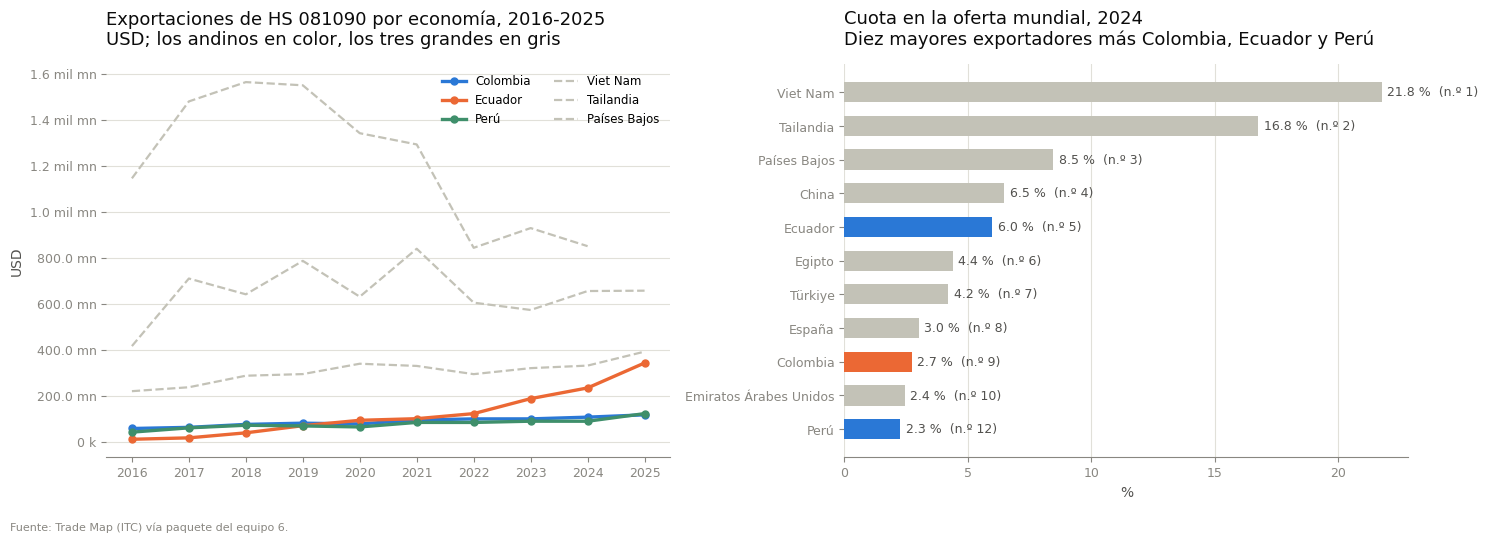

Figura guardada en salidas/g6_oferta_mundial.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for color, pais in zip(CATEGORIAS[:3], FOCO):
    axes[0].plot(ancho.index, ancho[pais], color=color, linewidth=2.4, marker="o", markersize=5, label=pais)
for pais in GRANDES:
    axes[0].plot(ancho.index, ancho[pais], color=GRIS_MID, linewidth=1.6, linestyle="--", label=pais)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
axes[0].set_xticks(ancho.index)
axes[0].legend(frameon=False, fontsize=8.5, ncol=2)
estilo(axes[0], "Exportaciones de HS 081090 por economía, 2016-2025", "USD; los andinos en color, los tres grandes en gris", eje_y="USD")
orden = resumen.sort_values("cuota_pct")
colores = [NARANJA if p == "Colombia" else (AZUL if p in FOCO else GRIS_MID) for p in orden["pais"]]
axes[1].barh(orden["pais"], orden["cuota_pct"], color=colores, height=0.6)
for y, (v, pu) in enumerate(zip(orden["cuota_pct"], orden["puesto"])):
    axes[1].annotate(f"{v:.1f} %  (n.º {pu})", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(axes[1], f"Cuota en la oferta mundial, {ANIO_RANKING}", "Diez mayores exportadores más Colombia, Ecuador y Perú", "Trade Map (ITC) vía paquete del equipo 6.", eje_x="%", rejilla="x")
plt.tight_layout()
guardar(fig, "g6_oferta_mundial")

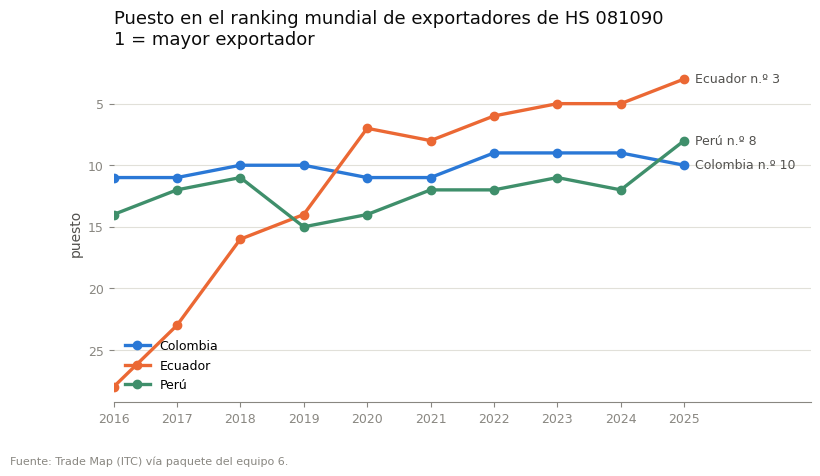

Figura guardada en salidas/g6_ranking.png


pais,anio,Colombia,Ecuador,Perú
0,2016,11,28,14
1,2017,11,23,12
2,2018,10,16,11
3,2019,10,14,15
4,2020,11,7,14
5,2021,11,8,12
6,2022,9,6,12
7,2023,9,5,11
8,2024,9,5,12
9,2025,10,3,8


In [22]:
puestos = cuotas[cuotas["pais"].isin(FOCO)].pivot(index="anio", columns="pais", values="puesto")[FOCO]
fig, ax = plt.subplots(figsize=(9, 4.4))
for color, pais in zip(CATEGORIAS[:3], FOCO):
    ax.plot(puestos.index, puestos[pais], color=color, linewidth=2.4, marker="o", markersize=6, label=pais)
    ax.annotate(f"{pais} n.º {puestos[pais].iloc[-1]}", (puestos.index[-1], puestos[pais].iloc[-1]), textcoords="offset points", xytext=(8, 0), va="center", fontsize=9, color=GRIS_TEXT)
ax.invert_yaxis()
ax.set_xticks(puestos.index)
ax.set_xlim(2016, 2027)
ax.legend(frameon=False, fontsize=9, loc="lower left")
estilo(ax, "Puesto en el ranking mundial de exportadores de HS 081090", "1 = mayor exportador", "Trade Map (ITC) vía paquete del equipo 6.", eje_y="puesto")
guardar(fig, "g6_ranking")
exportar(puestos.reset_index(), "g6_ranking")

**TRABAJO REALIZADO UNICAMENTE POR SERGIO BAUTISTA** 081090 está liderada por economías con una participación superior a la de Colombia, Ecuador y Perú. Colombia presenta una participación menor dentro de la oferta mundial, por lo que su posición corresponde a la de un exportador con menor peso frente a los principales participantes. Ecuador y Perú representan competidores regionales relevantes y deben ser considerados dentro del análisis competitivo. La comparación de los valores exportados, las cuotas de mercado y el CAGR permite observar no solamente el tamaño actual de cada exportador, sino también su evolución entre 2016 y 2024. El año 2024 se utiliza como referencia porque presenta una cobertura de datos mayor que 2025.

Para Colombia, estos resultados muestran que la estrategia de internacionalización debe ser focalizada.

***
# 3. HHI de la oferta mundial *(capa real)*

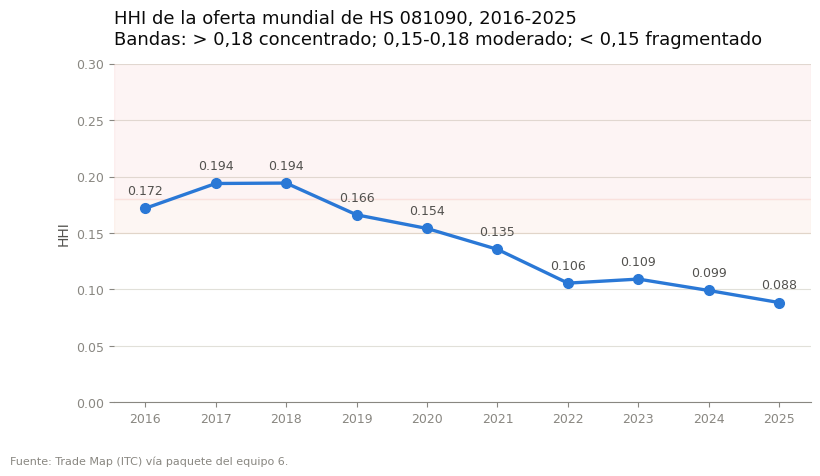

Figura guardada en salidas/g6_hhi_mundial.png


,anio,HHI,CR5,economias,numero_equivalente
0,2016,0.1718,67.3975,131,5.8198
1,2017,0.1938,69.8042,129,5.1590
2,2018,0.1942,69.9030,130,5.1489
3,2019,0.1661,67.9936,130,6.0206
4,2020,0.1540,67.1545,123,6.4929
5,2021,0.1355,65.9619,133,7.3804
6,2022,0.1056,58.7310,126,9.4683
7,2023,0.1092,60.5470,135,9.1583
8,2024,0.0991,59.4487,123,10.0922
9,2025,0.0884,56.3724,97,11.3145


In [10]:
hhi_mundial = (t2a.groupby("anio")["exportaciones_usd_miles"]
               .agg(HHI=hhi, CR5=lambda v: cr_n(v, 5), economias=lambda v: int((v > 0).sum())).reset_index())
hhi_mundial["numero_equivalente"] = numeros_equivalentes(hhi_mundial["HHI"])
exportar(hhi_mundial, "g6_hhi_mundial")
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(hhi_mundial["anio"], hhi_mundial["HHI"], color=AZUL, linewidth=2.4, marker="o", markersize=7)
for _, f in hhi_mundial.iterrows():
    ax.annotate(f"{f['HHI']:.3f}", (f["anio"], f["HHI"]), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color=GRIS_TEXT)
ax.axhspan(0.18, 1, color=ROJO, alpha=0.06)
ax.axhspan(0.15, 0.18, color=NARANJA, alpha=0.06)
ax.set_ylim(0, 0.3)
ax.set_xticks(hhi_mundial["anio"])
estilo(ax, "HHI de la oferta mundial de HS 081090, 2016-2025", "Bandas: > 0,18 concentrado; 0,15-0,18 moderado; < 0,15 fragmentado", "Trade Map (ITC) vía paquete del equipo 6.", eje_y="HHI")
guardar(fig, "g6_hhi_mundial")
hhi_mundial

El índice HHI revela el nivel de concentración o fragmentación global. Si los resultados históricos muestran un HHI inferior a 0,15, nos enfrentamos a un mercado altamente fragmentado con múltiples proveedores. En este escenario comercial, la entrada de curuba colombiana exige una alta especialización. La empresa exportadora no tendrá poder de fijación de precios globales, por lo que su éxito dependerá netamente de la calidad intrínseca del producto y de garantizar un trayecto logístico impecable que reduzca las mermas.

***
# 4. Posición comercial: IBCR, IAC y CE

Dos cálculos en paralelo. **(a)** Con las cifras de `d1` y `c1`, que son estimaciones del equipo. **(b)** IAC e IBCR de la economía completa de las seis economías con el Banco Mundial (capa real del curso). El coeficiente de exportación necesita el **valor** de la producción de curuba, que no está en el paquete: la celda tiene un parámetro editable de precio al productor para calcularlo.

In [11]:
# (a) estimaciones del equipo
d1["IBCR_recalculado"] = ibcr(d1["exportaciones_X_usd_miles"], d1["importaciones_M_usd_miles"])
d1["GL_recalculado"] = grubel_lloyd(d1["exportaciones_X_usd_miles"], d1["importaciones_M_usd_miles"])
tabla_a = d1[["pais", "exportaciones_X_usd_miles", "importaciones_M_usd_miles", "IBCR_calculado", "IBCR_recalculado", "IAC_pct", "GL_recalculado", "clasificacion_comercial"]]
exportar(tabla_a, "g6_posicion_equipo")
tabla_a

,pais,exportaciones_X_usd_miles,importaciones_M_usd_miles,IBCR_calculado,IBCR_recalculado,IAC_pct,GL_recalculado,clasificacion_comercial
0,Colombia,"2,091.3000",450,0.6460,0.6459,38.2000,0.3541,Pais origen / exportador neto
1,Paises Bajos,"15,200.0000",18400,-0.0950,-0.0952,154.2000,0.9048,Hub de reexportacion / distribuidor UE
2,Espana,"3,100.0000",8200,-0.4510,-0.4513,62.8000,0.5487,Mercado mixto (consumo / reexportacion regional)
3,Alemania,"1,800.0000",12500,-0.7480,-0.7483,87.1000,0.2517,Mercado de consumo final masivo
4,Canada,120.0000,5600,-0.9580,-0.9580,65.4000,0.0420,Mercado de consumo final puro
5,Emiratos Arabes Unidos,"2,400.0000",6800,-0.4780,-0.4783,168.5000,0.5217,Hub logistico / reexportacion Medio Oriente


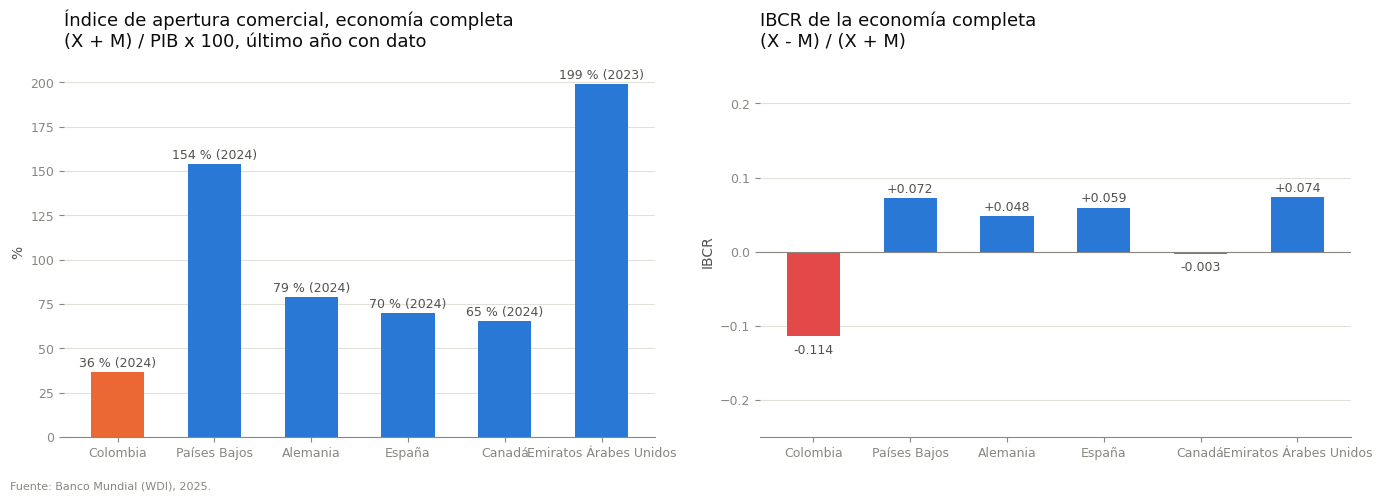

Figura guardada en salidas/g6_posicion_banco_mundial.png


,anio,IAC_pct,IBCR
economia,,,
Colombia,2024,36.3180,-0.1145
Países Bajos,2024,153.9563,0.0717
Alemania,2024,79.0907,0.0478
España,2024,69.9503,0.0595
Canadá,2024,65.1215,-0.0028
Emiratos Árabes Unidos,2023,199.0450,0.0736


In [12]:
# (b) Banco Mundial, economia completa, 2020-2024
ECONOMIAS = {"COL": "Colombia", "NLD": "Países Bajos", "DEU": "Alemania", "ESP": "España", "CAN": "Canadá", "ARE": "Emiratos Árabes Unidos"}
macro = wb_pib.merge(wb_exp, on=["iso3", "pais", "anio"]).merge(wb_imp, on=["iso3", "pais", "anio"])
macro = macro[macro["iso3"].isin(ECONOMIAS) & macro["anio"].between(2020, 2024)].copy()
macro["economia"] = macro["iso3"].map(ECONOMIAS)
macro["IAC_pct"] = apertura_comercial(macro["exportaciones_usd"], macro["importaciones_usd"], macro["pib_usd"])
macro["IBCR"] = ibcr(macro["exportaciones_usd"], macro["importaciones_usd"])
ultimo = macro.dropna(subset=["IAC_pct"]).sort_values("anio").groupby("economia").tail(1).set_index("economia").reindex(ECONOMIAS.values())
exportar(macro[["economia", "iso3", "anio", "pib_usd", "exportaciones_usd", "importaciones_usd", "IAC_pct", "IBCR"]], "g6_posicion_banco_mundial")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(ultimo.index, ultimo["IAC_pct"], color=[NARANJA if e == "Colombia" else AZUL for e in ultimo.index], width=0.55)
for x, (v, a) in enumerate(zip(ultimo["IAC_pct"], ultimo["anio"])):
    axes[0].annotate(f"{v:.0f} % ({a:.0f})", (x, v), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9, color=GRIS_TEXT)
axes[0].tick_params(axis="x", labelsize=8)
estilo(axes[0], "Índice de apertura comercial, economía completa", "(X + M) / PIB x 100, último año con dato", eje_y="%")
axes[1].bar(ultimo.index, ultimo["IBCR"], color=[ROJO if v < 0 else AZUL for v in ultimo["IBCR"]], width=0.55)
for x, v in enumerate(ultimo["IBCR"]):
    axes[1].annotate(f"{v:+.3f}", (x, v), textcoords="offset points", xytext=(0, 4 if v >= 0 else -12), ha="center", fontsize=9, color=GRIS_TEXT)
axes[1].axhline(0, color=GRIS_EJE, linewidth=0.8)
axes[1].set_ylim(-0.25, 0.25)
axes[1].tick_params(axis="x", labelsize=8)
estilo(axes[1], "IBCR de la economía completa", "(X - M) / (X + M)", "Banco Mundial (WDI), 2025.", eje_y="IBCR")
plt.tight_layout()
guardar(fig, "g6_posicion_banco_mundial")
ultimo[["anio", "IAC_pct", "IBCR"]]

In [13]:
# Coeficiente de exportacion de la curuba: CE = X / valor de la produccion x 100
# ====================== EDITABLE ======================
PRECIO_PRODUCTOR_USD_T = np.nan        # precio promedio al productor en USD por tonelada (Agronet / SIPSA). Ej.: 900
# ======================================================
produccion_t = c1.loc["Produccion estimada de curuba (ton)"]
exportado = c1.loc["Valor exportado imputado 3.8% (USD miles)"]
if pd.notna(PRECIO_PRODUCTOR_USD_T):
    valor_produccion_kusd = produccion_t * PRECIO_PRODUCTOR_USD_T / 1000
    ce = pd.DataFrame({"anio": produccion_t.index.astype(int), "produccion_t": produccion_t.values, "valor_produccion_kusd": valor_produccion_kusd.values,
                       "exportado_kusd": exportado.values, "CE_pct": coeficiente_exportacion(exportado.values, valor_produccion_kusd.values)})
    exportar(ce, "g6_coeficiente_exportacion")
    display(ce)
else:
    print("Escribe PRECIO_PRODUCTOR_USD_T para calcular el coeficiente de exportacion.")

Escribe PRECIO_PRODUCTOR_USD_T para calcular el coeficiente de exportacion.


Al cruzar el Índice de Apertura Comercial (IAC) y el Índice de Balanza Comercial Relativa (IBCR), podemos perfilar estratégicamente los mercados. Las economías que presentan un IAC muy alto acompañado de un IBCR cercano a cero actúan como hubs logísticos o plataformas de reexportación (como suele ser el caso de Países Bajos). Por el contrario, los países con un IBCR fuertemente negativo son importadores netos y consumidores finales. Seleccionar un hub facilitaría la distribución en un bloque económico, mientras que apuntar a un consumidor neto requiere adaptar el producto (empaque y normatividad) directamente a las preferencias del usuario final.

***
# 5. Colombia: concentración de destinos (HHI, Theil) y Grubel-Lloyd *(capa real, HS 081090 agregado)*

La vista por país socio que el plan del equipo marcaba como pendiente. Aplica al agregado HS 081090, no a la curuba sola.

In [14]:
paises_destino = serie_destinos[serie_destinos["codigo"] != "000"]
concentracion = (paises_destino.groupby("anio")["valor_kusd"]
                 .agg(HHI=hhi, Theil=theil, CR3=lambda v: cr_n(v, 3), destinos_activos=lambda v: int((v > 0).sum())).reset_index())
concentracion["numero_equivalente"] = numeros_equivalentes(concentracion["HHI"])
X_2025 = serie_destinos[(serie_destinos["codigo"] == "000") & (serie_destinos["anio"] == 2025)]["valor_kusd"].iloc[0]
M_2025 = separar_mundo(imp_2025)[0]["valor_kusd"]
print(f"Colombia 2025, HS 081090: X = {X_2025:,.0f}  M = {M_2025:,.0f}  ->  IBCR = {float(ibcr(X_2025, M_2025)):+.3f}   GL = {float(grubel_lloyd(X_2025, M_2025)):.3f}")
print(f"Comparar con la ficha del equipo: HHI curuba 0,0842 | Theil 1,845 | GL 0,021 (estimados con imputacion)")
exportar(concentracion, "g6_concentracion_destinos")
concentracion

Colombia 2025, HS 081090: X = 116,451  M = 2,886  ->  IBCR = +0.952   GL = 0.048
Comparar con la ficha del equipo: HHI curuba 0,0842 | Theil 1,845 | GL 0,021 (estimados con imputacion)


,anio,HHI,Theil,CR3,destinos_activos,numero_equivalente
0,2016,0.4670,2.0951,80.6234,34,2.1413
1,2017,0.4304,1.9878,77.8756,34,2.3233
2,2018,0.3916,1.9362,73.1576,36,2.5539
3,2019,0.4552,2.1358,77.9159,37,2.1969
4,2020,0.4593,2.0773,78.8353,34,2.1771
5,2021,0.4675,2.2463,78.0761,41,2.1390
6,2022,0.5101,2.1093,81.6630,31,1.9603
7,2023,0.4687,2.2407,79.9252,39,2.1334
8,2024,0.4377,2.0499,77.0998,35,2.2846
9,2025,0.4439,2.0050,78.5685,32,2.2528


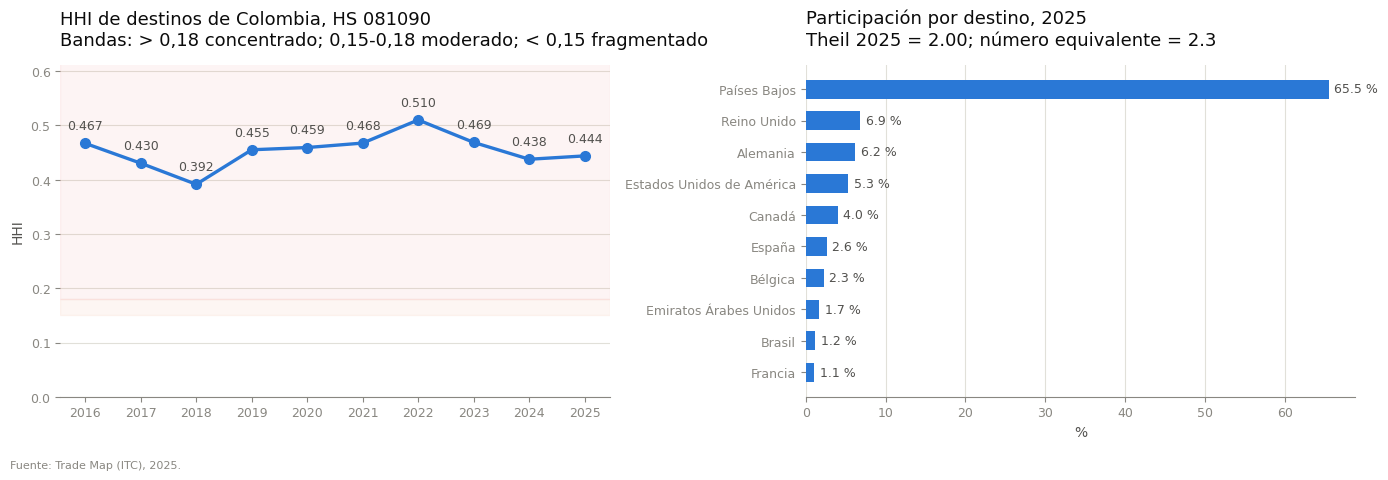

Figura guardada en salidas/g6_concentracion_destinos.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(concentracion["anio"], concentracion["HHI"], color=AZUL, linewidth=2.4, marker="o", markersize=7)
for _, f in concentracion.iterrows():
    axes[0].annotate(f"{f['HHI']:.3f}", (f["anio"], f["HHI"]), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color=GRIS_TEXT)
axes[0].axhspan(0.18, 1, color=ROJO, alpha=0.06)
axes[0].axhspan(0.15, 0.18, color=NARANJA, alpha=0.06)
axes[0].set_ylim(0, max(0.6, concentracion["HHI"].max() * 1.2))
axes[0].set_xticks(concentracion["anio"])
estilo(axes[0], "HHI de destinos de Colombia, HS 081090", "Bandas: > 0,18 concentrado; 0,15-0,18 moderado; < 0,15 fragmentado", eje_y="HHI")
destinos_2025 = paises_destino[paises_destino["anio"] == 2025].nlargest(10, "valor_kusd").copy()
destinos_2025["participacion_pct"] = destinos_2025["valor_kusd"] / X_2025 * 100
orden = destinos_2025.sort_values("participacion_pct")
axes[1].barh(orden["pais"], orden["participacion_pct"], color=AZUL, height=0.6)
for y, v in enumerate(orden["participacion_pct"]):
    axes[1].annotate(f"{v:.1f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(axes[1], "Participación por destino, 2025", f"Theil 2025 = {concentracion.iloc[-1]['Theil']:.2f}; número equivalente = {concentracion.iloc[-1]['numero_equivalente']:.1f}", "Trade Map (ITC), 2025.", eje_x="%", rejilla="x")
plt.tight_layout()
guardar(fig, "g6_concentracion_destinos")

Existe una divergencia esperada entre la dispersión del agregado HS 081090 y la realidad operativa de la curuba. Mientras que la partida general está altamente diversificada porque agrupa múltiples frutas exóticas (uchuva, pitahaya, etc.), la curuba (con un HHI estimado de 0,0842) requiere un enfoque distinto. La estrategia de concentrar la oferta en uno o dos mercados reduce artificialmente esta dispersión (bajando el índice de Theil) para el exportador, permitiéndole enfocar sus recursos financieros y logísticos en optimizar una única cadena de frío, algo vital dada la naturaleza perecedera de la Passiflora mollissima

***
# 6. Ventaja comparativa: Balassa, RSCA y Lafay

**Colombia, capítulo 08 (2021-2025):** con la canasta del curso. **Colombia, Ecuador y Perú en HS 081090:** numerador de Trade Map (`t2`, `t3`), denominador con exportaciones de bienes y servicios del Banco Mundial (aproximación). **Lafay:** sobre los 97 capítulos de Colombia, resaltando el 08.

In [16]:
ANIO_VCR = 2024
X_j = t3[ANIO_VCR]
totales_wb = wb_exp[wb_exp["anio"] == ANIO_VCR].set_index("iso3")["exportaciones_usd"] / 1000
X_w = totales_wb["WLD"]
filas = []
for pais, iso in {"Colombia": "COL", "Ecuador": "ECU", "Perú": "PER"}.items():
    X_ij, X_i = ancho.loc[ANIO_VCR, pais], totales_wb[iso]
    r = float(rca_balassa(X_ij, X_i, X_j, X_w))
    filas.append({"pais": pais, "X_ij_081090": X_ij, "X_i_total": X_i, "RCA": r, "RSCA": float(rsca_laursen(r))})
vcr = pd.DataFrame(filas)
vcr_cap08 = pd.DataFrame({"anio": [int(a) for a in ANIOS_CANASTA]})
vcr_cap08["RCA_cap08"] = rca_balassa(fila_canasta(canasta_co_exp, "08"), fila_canasta(canasta_co_exp, "TOTAL"), fila_canasta(canasta_mundo_exp, "08"), fila_canasta(canasta_mundo_exp, "TOTAL"))
vcr_cap08["RSCA_cap08"] = rsca_laursen(vcr_cap08["RCA_cap08"])
print("Comparar con la ficha: RCA curuba 12,45 / RSCA 0,851 (estimados con imputacion)")
exportar(vcr, "g6_vcr_andinos"); exportar(vcr_cap08, "g6_vcr_cap08")
display(vcr); vcr_cap08

Comparar con la ficha: RCA curuba 12,45 / RSCA 0,851 (estimados con imputacion)


,pais,X_ij_081090,X_i_total,RCA,RSCA
0,Colombia,"106,407.0000","67,618,959.7641",13.0871,0.8580
1,Ecuador,"233,457.0000","37,757,097.0000",51.4222,0.9618
2,Perú,"88,624.0000","84,269,317.2128",8.7463,0.7948


,anio,RCA_cap08,RSCA_cap08
0,2021,5.2593,0.6805
1,2022,4.5814,0.6417
2,2023,4.4095,0.6303
3,2024,5.4063,0.6878
4,2025,6.2188,0.7229


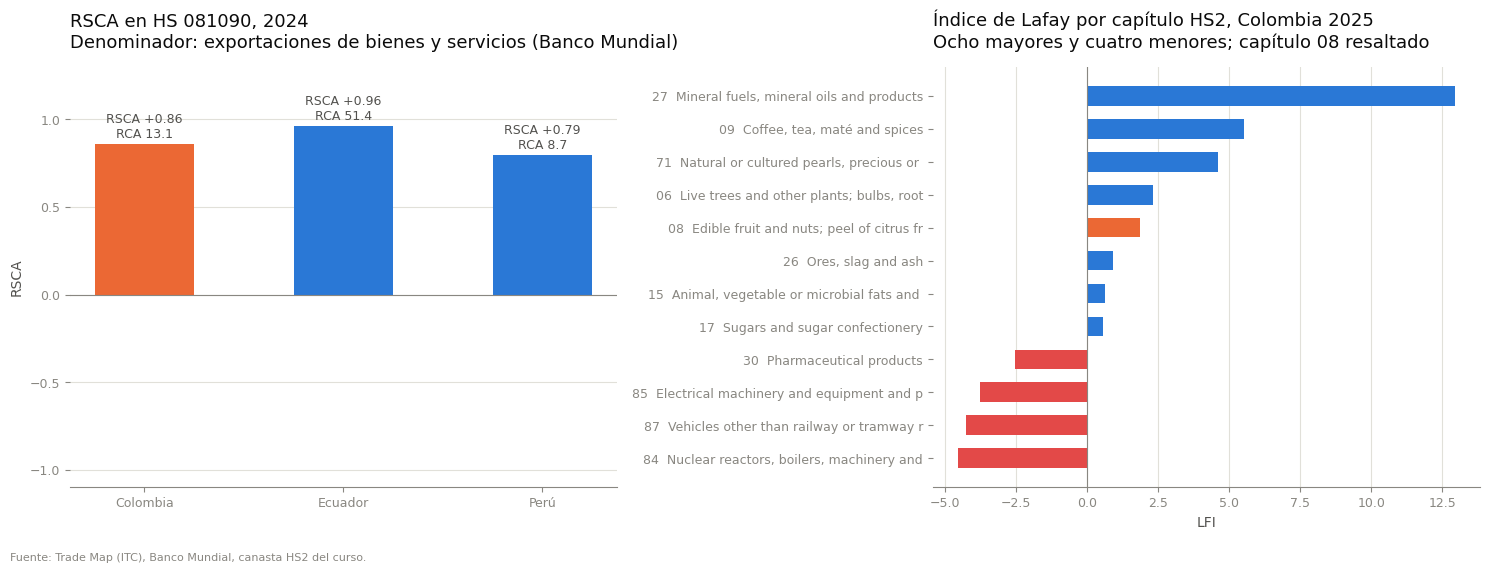

Figura guardada en salidas/g6_vcr.png


In [17]:
capitulos = canasta_co_exp[canasta_co_exp["codigo"] != "TOTAL"][["codigo", "producto", "2025"]].rename(columns={"2025": "X"})
capitulos = capitulos.merge(canasta_co_imp[["codigo", "2025"]].rename(columns={"2025": "M"}), on="codigo")
capitulos["LFI"] = lafay(capitulos["X"], capitulos["M"])
capitulos["producto"] = capitulos["producto"].str.slice(0, 40)
ranking_lafay = capitulos.sort_values("LFI", ascending=False).reset_index(drop=True)
exportar(ranking_lafay, "g6_lafay")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].bar(vcr["pais"], vcr["RSCA"], color=[NARANJA if p == "Colombia" else AZUL for p in vcr["pais"]], width=0.5)
for x, (v, r) in enumerate(zip(vcr["RSCA"], vcr["RCA"])):
    axes[0].annotate(f"RSCA {v:+.2f}\nRCA {r:.1f}", (x, v), textcoords="offset points", xytext=(0, 5 if v >= 0 else -24), ha="center", fontsize=9, color=GRIS_TEXT)
axes[0].axhline(0, color=GRIS_EJE, linewidth=0.8)
axes[0].set_ylim(-1.1, 1.3)
estilo(axes[0], f"RSCA en HS 081090, {ANIO_VCR}", "Denominador: exportaciones de bienes y servicios (Banco Mundial)", eje_y="RSCA")
extremos = pd.concat([ranking_lafay.head(8), ranking_lafay.tail(4)]).sort_values("LFI")
colores = [NARANJA if c == "08" else (AZUL if v >= 0 else ROJO) for c, v in zip(extremos["codigo"], extremos["LFI"])]
axes[1].barh(extremos["codigo"] + "  " + extremos["producto"], extremos["LFI"], color=colores, height=0.6)
axes[1].axvline(0, color=GRIS_EJE, linewidth=0.8)
axes[1].tick_params(axis="y", labelsize=8)
estilo(axes[1], "Índice de Lafay por capítulo HS2, Colombia 2025", "Ocho mayores y cuatro menores; capítulo 08 resaltado", "Trade Map (ITC), Banco Mundial, canasta HS2 del curso.", eje_x="LFI", rejilla="x")
plt.tight_layout()
guardar(fig, "g6_vcr")

El cálculo del RSCA y el Índice de Lafay permite confirmar la posición estructural de Colombia frente a la competencia andina. Un RSCA positivo y superior al de Ecuador y Perú ratifica que Colombia tiene una especialización exportadora revelada en esta subpartida. Por su parte, un Índice de Lafay positivo para el capítulo 08 valida que las frutas aportan superávit al comercio nacional. Esto indica que el entorno macroeconómico y la base productiva del país son favorables para respaldar el proyecto exportador de curuba a largo plazo.

***
# 7. Matriz multicriterio *(capa del equipo, editable)*

Los cinco criterios y pesos de la ficha (30/25/20/15/10) con los puntajes 1-5 del equipo, tal como están en `i4`. Cambia pesos o puntajes y vuelve a ejecutar; la prueba de sensibilidad mueve cada peso ±5 puntos.

In [18]:
criterios = i4[i4["criterio"].str.match(r"^\d")].copy()
MERCADOS = [c for c in criterios.columns if c not in ("criterio", "peso")]
# ====================== EDITABLE ======================
PESOS = dict(zip(criterios["criterio"], criterios["peso"] * 100))
PUNTAJES = criterios.set_index("criterio")[MERCADOS].astype(float)
# ======================================================
matriz = matriz_multicriterio(PUNTAJES, PESOS)
exportar(matriz.reset_index().rename(columns={"index": "mercado"}), "g6_matriz_multicriterio")
matriz.round(2)

criterio,1. Absorcion / volumen,2. Logistica y cadena de frio,3. Acceso fitosanitario,4. Rol de hub,5. Afinidad / precio,Total
Paises Bajos,1.3500,1.2500,0.9000,0.7500,0.3500,4.6000
Alemania,1.5000,1.1200,0.8000,0.3000,0.4000,4.1200
Espana,1.0500,1.0000,0.9000,0.4500,0.5000,3.9000
E.A.U.,0.7500,0.8800,0.7000,0.6800,0.4500,3.4500
Canada,0.9000,0.8800,0.6000,0.2200,0.4000,3.0000


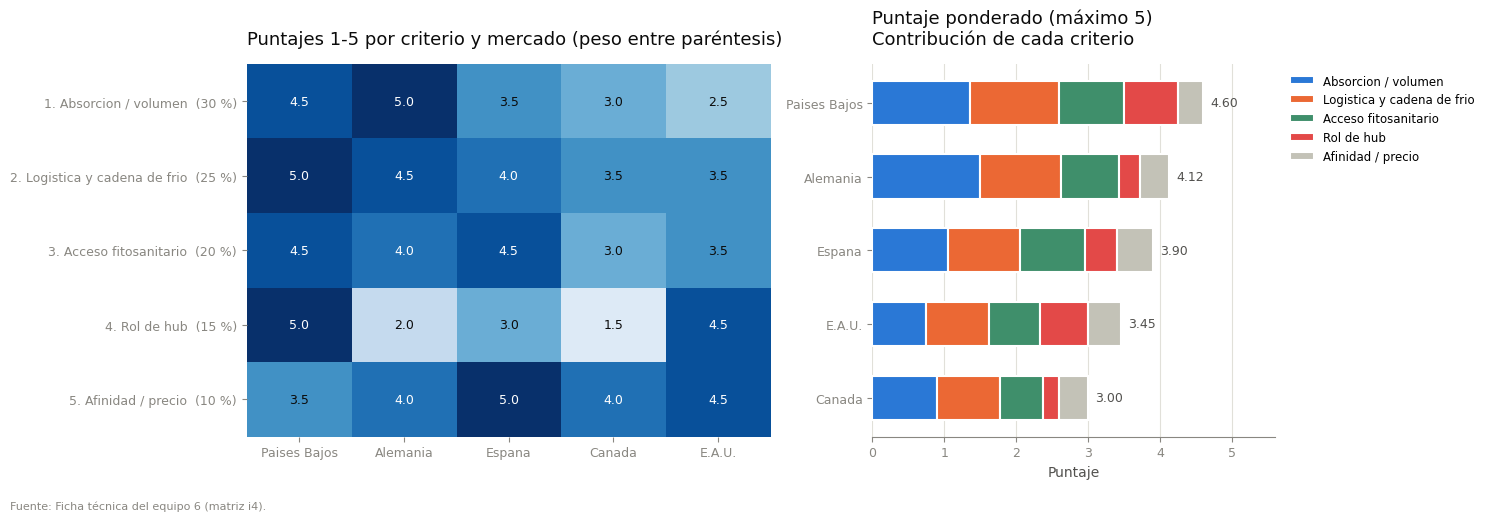

Figura guardada en salidas/g6_matriz_multicriterio.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.3, 1]})
im = axes[0].imshow(PUNTAJES.values, cmap="Blues", vmin=1, vmax=5, aspect="auto")
axes[0].set_xticks(range(len(MERCADOS))); axes[0].set_xticklabels(MERCADOS, fontsize=9)
axes[0].set_yticks(range(len(PUNTAJES))); axes[0].set_yticklabels([f"{c}  ({PESOS[c]:.0f} %)" for c in PUNTAJES.index], fontsize=9)
for i in range(PUNTAJES.shape[0]):
    for j in range(PUNTAJES.shape[1]):
        v = PUNTAJES.iloc[i, j]
        axes[0].text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9, color="white" if v >= 4 else TINTA)
axes[0].set_title("Puntajes 1-5 por criterio y mercado (peso entre paréntesis)", fontsize=13, color=TINTA, loc="left", pad=14)
axes[0].tick_params(colors=GRIS_EJE)
for lado in axes[0].spines.values(): lado.set_visible(False)
acumulado = np.zeros(len(matriz))
for color, criterio in zip(CATEGORIAS + [GRIS_MID], PESOS.keys()):
    axes[1].barh(matriz.index, matriz[criterio], left=acumulado, color=color, height=0.6, label=criterio.split(". ", 1)[-1], edgecolor="white", linewidth=1.5)
    acumulado += matriz[criterio].values
for y, t in enumerate(matriz["Total"]):
    axes[1].annotate(f"{t:.2f}", (t, y), textcoords="offset points", xytext=(5, 0), va="center", fontsize=9, color=GRIS_TEXT)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 5.6)
leyenda_fuera(axes[1])
estilo(axes[1], "Puntaje ponderado (máximo 5)", "Contribución de cada criterio", "Ficha técnica del equipo 6 (matriz i4).", eje_x="Puntaje", rejilla="x")
plt.tight_layout()
guardar(fig, "g6_matriz_multicriterio")

In [20]:
def sensibilidad(puntajes, pesos, delta=5):
    base = matriz_multicriterio(puntajes, pesos).index.tolist()
    filas = []
    for criterio in pesos:
        for signo in (+delta, -delta):
            alterados = dict(pesos); alterados[criterio] = max(0, alterados[criterio] + signo)
            orden = matriz_multicriterio(puntajes, alterados).index.tolist()
            filas.append({"peso_modificado": criterio, "cambio": f"{signo:+d}", "primero": orden[0], "segundo": orden[1],
                          "cambia_el_lider": orden[0] != base[0], "cambia_el_orden": orden != base})
    return pd.DataFrame(filas)
prueba = sensibilidad(PUNTAJES, PESOS)
print("Orden base:", " > ".join(matriz.index))
print(f"El líder cambia en {prueba['cambia_el_lider'].sum()} de {len(prueba)} escenarios; el orden completo cambia en {prueba['cambia_el_orden'].sum()}.")
exportar(prueba, "g6_sensibilidad_pesos")
prueba

Orden base: Paises Bajos > Alemania > Espana > E.A.U. > Canada
El líder cambia en 0 de 10 escenarios; el orden completo cambia en 0.


,peso_modificado,cambio,primero,segundo,cambia_el_lider,cambia_el_orden
0,1. Absorcion / volumen,+5,Paises Bajos,Alemania,False,False
1,1. Absorcion / volumen,-5,Paises Bajos,Alemania,False,False
2,2. Logistica y cadena de frio,+5,Paises Bajos,Alemania,False,False
3,2. Logistica y cadena de frio,-5,Paises Bajos,Alemania,False,False
4,3. Acceso fitosanitario,+5,Paises Bajos,Alemania,False,False
5,3. Acceso fitosanitario,-5,Paises Bajos,Alemania,False,False
6,4. Rol de hub,+5,Paises Bajos,Alemania,False,False
7,4. Rol de hub,-5,Paises Bajos,Alemania,False,False
8,5. Afinidad / precio,+5,Paises Bajos,Alemania,False,False
9,5. Afinidad / precio,-5,Paises Bajos,Alemania,False,False


La prueba de sensibilidad es crucial para validar la estrategia de selección de mercados. Al variar los pesos de los criterios en ±5 puntos porcentuales, evaluamos si los dos mercados prioritarios mantienen su posición de liderazgo. Si el orden del ranking (el primer y segundo lugar) no cambia, significa que la elección es matemáticamente robusta y no depende exclusivamente de sesgos en el juicio experto. Si el líder cambia, el equipo debe enfocar su gestión de riesgos en los criterios que causaron la volatilidad (por ejemplo, barreras arancelarias o costos logísticos).

***
# 8. Sensibilidad al factor de imputación *(capa del equipo)*

El paquete imputa la curuba como el 3,8 % de la base comercial regional, pero la participación productiva real de la curuba en las pasifloras es de 12,5 % (hoja `c2`). Esta celda recalcula el valor imputado con ambos factores y lo compara con las exportaciones reales de Colombia en HS 081090.

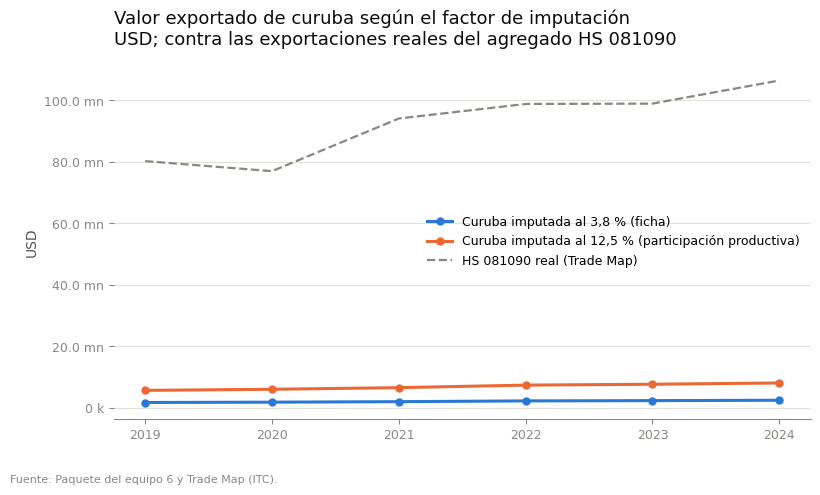

Figura guardada en salidas/g6_sensibilidad_factor.png


,"3,8 % (ficha)","12,5 % (participación productiva)",Colombia exporta HS 081090 (real),"3,8 % (ficha) como % del 081090 real","12,5 % (participación productiva) como % del 081090 real"
anio,,,,,
2019,"1,717.6000","5,655.3000",80197,2.1000,7.1000
2020,"1,827.8000","6,018.1000",76931,2.4000,7.8000
2021,"1,987.4000","6,543.6000",94058,2.1000,7.0000
2022,"2,238.2000","7,369.4000",98775,2.3000,7.5000
2023,"2,325.6000","7,657.1000",98897,2.4000,7.7000
2024,"2,451.0000","8,070.0000",106407,2.3000,7.6000


In [21]:
# ====================== EDITABLE ======================
FACTORES = {"3,8 % (ficha)": 0.038, "12,5 % (participación productiva)": c2["participacion_curuba_en_pasifloras_pct"].mean() / 100}
# ======================================================
base_regional = c2.set_index("anio")["base_comercio_america_latina_usd_miles"]
exportaciones_reales = serie_destinos[serie_destinos["codigo"] == "000"].set_index("anio")["valor_kusd"]
sens = pd.DataFrame({nombre: base_regional * f for nombre, f in FACTORES.items()})
sens["Colombia exporta HS 081090 (real)"] = exportaciones_reales.reindex(sens.index)
for nombre in FACTORES:
    sens[f"{nombre} como % del 081090 real"] = sens[nombre] / sens["Colombia exporta HS 081090 (real)"] * 100
exportar(sens.reset_index(), "g6_sensibilidad_factor")
fig, ax = plt.subplots(figsize=(9, 4.6))
for color, nombre in zip([AZUL, NARANJA], FACTORES):
    ax.plot(sens.index, sens[nombre], color=color, linewidth=2.2, marker="o", markersize=5, label=f"Curuba imputada al {nombre}")
ax.plot(sens.index, sens["Colombia exporta HS 081090 (real)"], color=GRIS_EJE, linewidth=1.6, linestyle="--", label="HS 081090 real (Trade Map)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
ax.set_xticks(sens.index)
ax.legend(frameon=False, fontsize=9)
estilo(ax, "Valor exportado de curuba según el factor de imputación", "USD; contra las exportaciones reales del agregado HS 081090", "Paquete del equipo 6 y Trade Map (ITC).", eje_y="USD")
guardar(fig, "g6_sensibilidad_factor")
sens.round(1)

La brecha entre el factor de imputación comercial (3,8 %) y la participación productiva real de la curuba dentro de las pasifloras (12,5 %) demuestra que las exportaciones potenciales podrían estar subestimadas. Si el mercado internacional refleja la estructura de producción interna (12,5 %), el techo de demanda es sustancialmente mayor. Esto apoya la viabilidad del proyecto: justifica un mayor presupuesto para invertir en empaques especializados e infraestructura de control térmico, asegurando que el producto llegue fresco a los dos mercados seleccionados.

En conclusión, se recomienda adoptar una estrategia de entrada concentrada enfocada de manera exclusiva en los Países Bajos y Canadá, sustentada en la necesidad de competir por diferenciación mediante un estricto manejo poscosecha ante la creciente presión de Ecuador y Perú en un mercado global fragmentado. La elección de estos destinos se fundamenta en un análisis de complementariedad comercial: los Países Bajos operan como el principal hub logístico y de reexportación para Europa (evidenciado por su alto Índice de Apertura Comercial - IAC), mientras que Canadá representa un mercado de consumo directo altamente dependiente de importaciones agrícolas (reflejado en un IBCR negativo). Dado que el RSCA y el Índice de Lafay validan la ventaja comparativa estructural de Colombia en la subpartida 081090, y el análisis de sensibilidad productiva (12,5 % frente al 3,8 % imputado) garantiza un volumen de abastecimiento robusto, la empresa debe no diluir esfuerzos logísticos y canalizar toda su inversión hacia una cadena de frío ininterrumpida exclusiva para estos dos mercados, asegurando la entrega de una curuba fresca de calidad premium.

***
# Entrega

1. Revisa que todas las celdas **Análisis del equipo** tengan texto.  
2. `Archivo → Descargar → Descargar .ipynb`.  
3. Sube el archivo al aula virtual. Las figuras y tablas de `salidas/` pueden ir al informe escrito.

# Referencias

Balassa, B. (1965). Trade liberalisation and "revealed" comparative advantage. *The Manchester School, 33*(2), 99–123.

Lafay, G. (1992). The measurement of revealed comparative advantages. En M. G. Dagenais & P. A. Muet (Eds.), *International Trade Modelling* (pp. 209–234). Chapman & Hall.

Grubel, H. G., & Lloyd, P. J. (1975). *Intra-industry trade*. Macmillan.

World Bank. (2025). *World Development Indicators*. https://data.worldbank.org

Baena-Rojas, J. J., & Cano, J. A. (2026). International market selection for exports of goods: A data analysis technique for organizational decision-making. *Global Business Review*. https://doi.org/10.1177/09721509261464305

International Trade Centre. (2025). *Trade Map: Trade statistics for international business development*. https://www.trademap.org

Durán Lima, J. E. (s.f.). *Indicadores de comercio exterior y política comercial: Generalidades metodológicas e indicadores básicos*. CEPAL.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55


::: {.pie-ean}
**Equipo 6 · Curuba fresca · HS 081090** · Proyecto final de Inteligencia en Negocios Globales, Universidad EAN, septiembre de 2026. Docente: Alejandra Otero. Sitio construido con [Quarto](https://quarto.org) a partir del cuaderno de análisis del equipo.
:::
